# House Price Prediction — Feature Engineering & Categorical Encoding


### Encoding methods
1. Label Encoding
2. One-Hot Encoding
3. Frequency Encoding
4. Binary Encoding
5. Feature Hashing




In [1]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction import FeatureHasher
from joblib import dump
warnings.filterwarnings("ignore")

BASE_PATH = Path.cwd()
for candidate in [BASE_PATH, BASE_PATH / "data", BASE_PATH / "dataset", BASE_PATH.parent]:
    if (candidate / "train.csv").exists():
        BASE_PATH = candidate
        break

TRAIN_FILE = BASE_PATH / "train.csv"
TEST_FILE = BASE_PATH / "test.csv"
print("Working directory:", BASE_PATH)
print("Training file:", TRAIN_FILE)
print("Testing file:", TEST_FILE)


Working directory: /home/student/Jupyter/House Prices
Training file: /home/student/Jupyter/House Prices/train.csv
Testing file: /home/student/Jupyter/House Prices/test.csv


In [2]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
print("=" * 70)
print("HOUSE PRICES DATASET LOADED")
print("=" * 70)
print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)
display(train_df.head())


HOUSE PRICES DATASET LOADED
Training dataset shape: (1460, 81)
Testing dataset shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 3. Exploratory Data Analysis

The dataset is inspected for dimensions, data types, missing values, and target statistics before preprocessing. This establishes the data-quality issues that the modelling pipeline must address.


In [3]:
print("Column count:", train_df.shape[1])
print("Row count:", train_df.shape[0])
print("\nData types:")
display(train_df.dtypes)
print("\nMissing values:")
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
display(missing_values)
print("\nSalePrice statistics:")
display(train_df["SalePrice"].describe())


Column count: 81
Row count: 1460

Data types:


Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object


Missing values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


SalePrice statistics:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

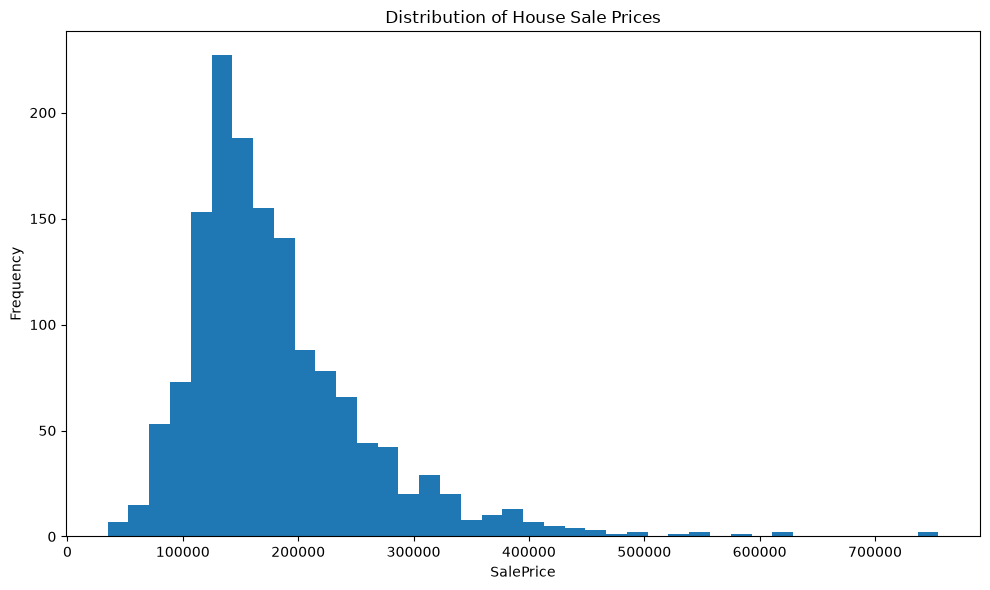

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(train_df["SalePrice"], bins=40)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of House Sale Prices")
plt.tight_layout()
plt.show()


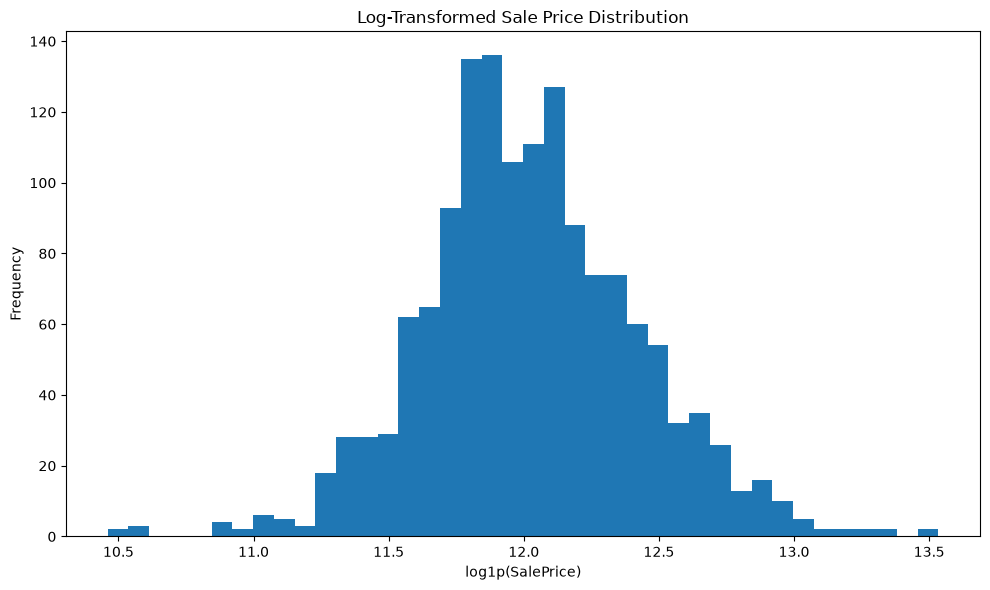

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(np.log1p(train_df["SalePrice"]), bins=40)
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Sale Price Distribution")
plt.tight_layout()
plt.show()


# 4. Separate Features and Target

`SalePrice` is the target variable because it is the value the model must predict. All remaining columns are candidate input features.


In [6]:
X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]
print("Input features:", X.shape[1])
print("Observations:", X.shape[0])
print("Target:", "SalePrice")
print("Target minimum:", y.min())
print("Target maximum:", y.max())
print("Target mean:", round(y.mean(), 2))


Input features: 80
Observations: 1460
Target: SalePrice
Target minimum: 34900
Target maximum: 755000
Target mean: 180921.2


# 5. Train–Validation Split

An 80/20 split is used. The validation data remains unseen during model fitting and is used to compare the encoding strategies. `random_state=42` makes the experiment reproducible.


In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_valid.shape[0])


Training samples: 1168
Validation samples: 292


# 6. Identify Feature Types

Numerical features represent quantities or measurements. Categorical features represent labels or groups. They require different preprocessing before entering the regression model.


In [8]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X_train.select_dtypes(exclude=["object"]).columns.tolist()
print("Numerical features:", len(numerical_columns))
print("Categorical features:", len(categorical_columns))
print("\nCategorical features:")
print(categorical_columns)


Numerical features: 37
Categorical features: 43

Categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


# 7. Missing-Value Handling

Numerical missing values are replaced with the median calculated from the training split. Categorical missing values are replaced with the most frequent training category.

The validation set receives values learned from the training set only, reducing the risk of data leakage.


In [9]:
X_train_clean = X_train.copy()
X_valid_clean = X_valid.copy()

numeric_fill_values = {}
categorical_fill_values = {}

for column in numerical_columns:
    value = X_train_clean[column].median()
    numeric_fill_values[column] = value
    X_train_clean[column] = X_train_clean[column].fillna(value)
    X_valid_clean[column] = X_valid_clean[column].fillna(value)

for column in categorical_columns:
    value = X_train_clean[column].mode()[0]
    categorical_fill_values[column] = value
    X_train_clean[column] = X_train_clean[column].fillna(value)
    X_valid_clean[column] = X_valid_clean[column].fillna(value)

print("Training missing values after preprocessing:", X_train_clean.isnull().sum().sum())
print("Validation missing values after preprocessing:", X_valid_clean.isnull().sum().sum())


Training missing values after preprocessing: 0
Validation missing values after preprocessing: 0


# 8. Encoding Experiments

Machine-learning estimators require numerical inputs. The following five strategies transform categorical variables into numerical representations. The same Ridge regression model is used for every experiment so the comparison isolates the effect of encoding as much as possible.


In [10]:
results = []
models = {}
predictions_by_method = {}

def evaluate_regression(X_train_encoded, X_valid_encoded, method_name):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])
    model.fit(X_train_encoded, np.log1p(y_train))
    predictions = np.expm1(model.predict(X_valid_encoded))
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    r2 = r2_score(y_valid, predictions)
    results.append({
        "Encoding Method": method_name,
        "Number of Features": X_train_encoded.shape[1],
        "RMSE": rmse,
        "R2 Score": r2
    })
    models[method_name] = model
    predictions_by_method[method_name] = predictions
    print(method_name)
    print("Number of features:", X_train_encoded.shape[1])
    print("RMSE:", round(rmse, 2))
    print("R² Score:", round(r2, 4))
    return model, predictions


## 8.1 Label Encoding

Label Encoding assigns an integer to each category. It is compact, but the integer representation can imply an ordering that may not exist in the original categories.


In [11]:
X_train_label = X_train_clean.copy()
X_valid_label = X_valid_clean.copy()
label_mappings = {}

for column in categorical_columns:
    categories = X_train_clean[column].astype(str).unique()
    mapping = {category: index for index, category in enumerate(categories)}
    label_mappings[column] = mapping
    X_train_label[column] = X_train_clean[column].astype(str).map(mapping)
    X_valid_label[column] = X_valid_clean[column].astype(str).map(mapping).fillna(-1)

evaluate_regression(X_train_label.values, X_valid_label.values, "Label Encoding")


Label Encoding
Number of features: 80
RMSE: 27656.72
R² Score: 0.9003


(Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
 array([150919.63083262, 324585.1448714 , 107910.06710623, 165990.8480898 ,
        312560.86425033,  92460.15673808, 237367.06262019, 150248.26555226,
         86603.84870046, 145168.52055068, 140598.93967147, 120061.22961808,
        105758.96143519, 201988.22950561, 179818.30521745, 133610.75036076,
        201773.50231679, 125019.81083029, 115407.60010112, 217827.63697714,
        139789.11012385, 193280.32568031, 189869.69000109, 129379.95735859,
        203983.43951366, 152648.33572087, 193113.15120199,  97890.83337475,
        172083.04886328, 196273.96683203, 110975.39773888, 263189.98055987,
        162040.25443461, 106867.74489579, 267155.80012842, 141809.80559851,
        122375.44440725, 207006.17644464, 353455.85163565,  99655.10795852,
        127215.72874917, 250327.28174314, 108265.26176297, 339930.57372578,
        126511.49626335, 129896.98423987, 107501.09607472, 132508.3556749 ,
        4

## 8.2 One-Hot Encoding

One-Hot Encoding creates a binary feature for each category. It avoids imposing an ordinal relationship but can increase dimensionality when many categories exist.


In [12]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = ohe.fit_transform(X_train_clean[categorical_columns])
X_valid_cat = ohe.transform(X_valid_clean[categorical_columns])
X_train_ohe = np.hstack([X_train_clean[numerical_columns].values, X_train_cat])
X_valid_ohe = np.hstack([X_valid_clean[numerical_columns].values, X_valid_cat])
evaluate_regression(X_train_ohe, X_valid_ohe, "One-Hot Encoding")


One-Hot Encoding
Number of features: 286
RMSE: 22167.46
R² Score: 0.9359


(Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
 array([152859.92957657, 342524.61707791,  98421.07939309, 165782.77897432,
        313545.40951732,  81018.21321212, 249607.89555786, 146116.92569454,
         76685.36011535, 142402.82776699, 145371.88535875, 114525.77988898,
         78621.19560893, 210305.07334612, 173512.81157034, 132100.09287491,
        188082.51752637, 131338.45040624, 107637.79968697, 213067.66563858,
        153637.29376948, 202887.09647276, 175110.93755553, 135674.5076048 ,
        198884.77996859, 148587.08990188, 189931.05862698, 111148.46537994,
        180820.4209149 , 198086.2298324 , 175494.02438449, 279268.58803627,
        218123.19342858, 116655.72489565, 256691.84248534, 150529.83561895,
        143684.66798294, 198668.50684287, 321822.28694588, 103986.61638208,
        134048.53116659, 222507.72438575, 110045.35620764, 371602.0038433 ,
        128497.50233926, 127924.35703271, 105654.57962021, 135289.15192709,
        4

## 8.3 Frequency Encoding

Frequency Encoding replaces each category with its relative frequency in the training data. It keeps one numerical feature per original categorical variable and therefore controls dimensionality.


In [13]:
X_train_freq = X_train_clean.copy()
X_valid_freq = X_valid_clean.copy()
frequency_mappings = {}

for column in categorical_columns:
    mapping = X_train_clean[column].value_counts(normalize=True).to_dict()
    frequency_mappings[column] = mapping
    X_train_freq[column] = X_train_clean[column].map(mapping).fillna(0)
    X_valid_freq[column] = X_valid_clean[column].map(mapping).fillna(0)

evaluate_regression(X_train_freq.values, X_valid_freq.values, "Frequency Encoding")


Frequency Encoding
Number of features: 80
RMSE: 27510.3
R² Score: 0.9013


(Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
 array([156288.91062711, 321564.35926688, 107714.18730112, 161010.09531335,
        314750.424843  ,  91637.23534745, 246773.20661106, 145510.5463369 ,
         88179.12330489, 146869.1825482 , 146623.09558106, 124068.06040323,
         98030.62150622, 196322.78127153, 175379.14874253, 133592.93028291,
        211144.76035862, 125922.99065268, 115441.54795285, 220789.35923598,
        164646.16135286, 195532.06437228, 191349.96084586, 134946.96396689,
        211061.90220232, 152202.93916545, 199037.16659923, 101119.11881454,
        177244.73635311, 189774.73411099, 118991.27622722, 257794.47496793,
        173444.34158297, 107536.37462622, 266749.18034843, 153579.97931401,
        119363.6591053 , 211234.45738721, 326396.63407439,  98426.95123719,
        130557.01899793, 247474.05748477, 108589.29117412, 328670.38439657,
        132268.52201975, 131902.10303357, 106274.13562602, 138191.13615643,
        4

## 8.4 Binary Encoding

Binary Encoding first maps categories to integers and then represents those integers with binary digits. It can use fewer columns than One-Hot Encoding for higher-cardinality variables.


In [14]:
def binary_encode(train_column, valid_column, column_name):
    categories = train_column.astype(str).unique()
    mapping = {category: index for index, category in enumerate(categories)}
    train_numbers = train_column.astype(str).map(mapping).fillna(0).astype(int)
    valid_numbers = valid_column.astype(str).map(mapping).fillna(0).astype(int)
    bits = max(1, int(np.ceil(np.log2(len(categories)))))
    train_binary = pd.DataFrame(index=train_column.index)
    valid_binary = pd.DataFrame(index=valid_column.index)
    for bit in range(bits):
        train_binary[f"{column_name}_binary_{bit}"] = (train_numbers // (2 ** bit)) % 2
        valid_binary[f"{column_name}_binary_{bit}"] = (valid_numbers // (2 ** bit)) % 2
    return train_binary, valid_binary, mapping

X_train_binary = X_train_clean[numerical_columns].copy()
X_valid_binary = X_valid_clean[numerical_columns].copy()
binary_mappings = {}

for column in categorical_columns:
    train_binary, valid_binary, mapping = binary_encode(X_train_clean[column], X_valid_clean[column], column)
    binary_mappings[column] = mapping
    X_train_binary = pd.concat([X_train_binary, train_binary], axis=1)
    X_valid_binary = pd.concat([X_valid_binary, valid_binary], axis=1)

evaluate_regression(X_train_binary.values, X_valid_binary.values, "Binary Encoding")


Binary Encoding
Number of features: 149
RMSE: 28050.21
R² Score: 0.8974


(Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
 array([153385.18757112, 317096.21684233, 102675.18398691, 161489.64128997,
        329610.18981654,  90267.97403948, 248234.69858515, 143623.86838935,
         83537.24213382, 148617.64558457, 139460.83679377, 121734.46389511,
         91141.82256829, 201416.8151486 , 165570.96338307, 137729.36626066,
        193545.13302384, 129697.9806741 , 109574.98054574, 215013.34872341,
        144708.23405046, 201667.33763471, 184561.59772925, 136917.94634373,
        200861.75444336, 157720.84412421, 191956.95287814, 102589.75373281,
        170938.57619305, 208657.3630785 , 159945.96904289, 263570.04806047,
        171883.69549319, 115463.65023757, 252590.521161  , 147441.92245788,
        131909.05869554, 208055.92846391, 324030.1512121 , 100518.23383044,
        133237.87214983, 241672.42237922, 112508.49916882, 334745.38703664,
        134882.00545921, 136278.98016373, 104451.09844784, 138186.46690323,
        4

## 8.5 Feature Hashing

Feature Hashing maps categorical values into a fixed number of numerical dimensions. For this experiment, 32 hashed categorical features are used. The fixed dimensionality can be useful for high-cardinality data, although hashing can introduce collisions.


In [15]:
HASH_FEATURES = 32

def create_hash_data(data):
    records = []
    for _, row in data.iterrows():
        record = {}
        for column in categorical_columns:
            record[f"{column}={str(row[column])}"] = 1
        records.append(record)
    return records

hasher = FeatureHasher(n_features=HASH_FEATURES, input_type="dict")
X_train_hash_cat = hasher.transform(create_hash_data(X_train_clean)).toarray()
X_valid_hash_cat = hasher.transform(create_hash_data(X_valid_clean)).toarray()
X_train_hash = np.hstack([X_train_clean[numerical_columns].values, X_train_hash_cat])
X_valid_hash = np.hstack([X_valid_clean[numerical_columns].values, X_valid_hash_cat])
evaluate_regression(X_train_hash, X_valid_hash, "Feature Hashing")


Feature Hashing
Number of features: 69
RMSE: 28391.8
R² Score: 0.8949


(Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
 array([160178.99352086, 314893.49542136, 120155.79349393, 151117.93394405,
        333341.20648993,  85421.2724597 , 236948.41202671, 145069.27061945,
         85234.62930059, 150213.8029899 , 146712.85116392, 128205.99958282,
        100000.36841673, 192835.29718166, 175489.11573042, 136122.98010616,
        199103.16408027, 127854.99845489, 114362.37075725, 218755.82410176,
        164248.20503935, 194715.77026321, 185788.77223707, 133238.84202159,
        209012.65691733, 153503.66853022, 198500.10382985,  96025.88594971,
        175139.88399478, 200471.60382703, 134667.18676891, 257488.57169069,
        197315.32165356, 106775.68672468, 266607.08273856, 155643.7265515 ,
        135775.15551865, 212913.46083614, 346808.81813228, 103763.45034091,
        138654.63300073, 240731.06787639, 108868.19063769, 308704.34813575,
        125379.3963376 , 119933.24568354, 105417.21206821, 133968.47486933,
        4

# 9. Encoding Performance Comparison

The five experiments are combined into one table. RMSE measures prediction error in the original house-price scale, while R² measures the proportion of target variance explained by the model.


In [16]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_display = results_df.copy()
results_display["RMSE"] = results_display["RMSE"].round(2)
results_display["R2 Score"] = results_display["R2 Score"].round(4)
display(results_display)


,Encoding Method,Number of Features,RMSE,R2 Score
0,One-Hot Encoding,286,22167.46,0.9359
1,Frequency Encoding,80,27510.30,0.9013
2,Label Encoding,80,27656.72,0.9003
3,Binary Encoding,149,28050.21,0.8974
4,Feature Hashing,69,28391.80,0.8949


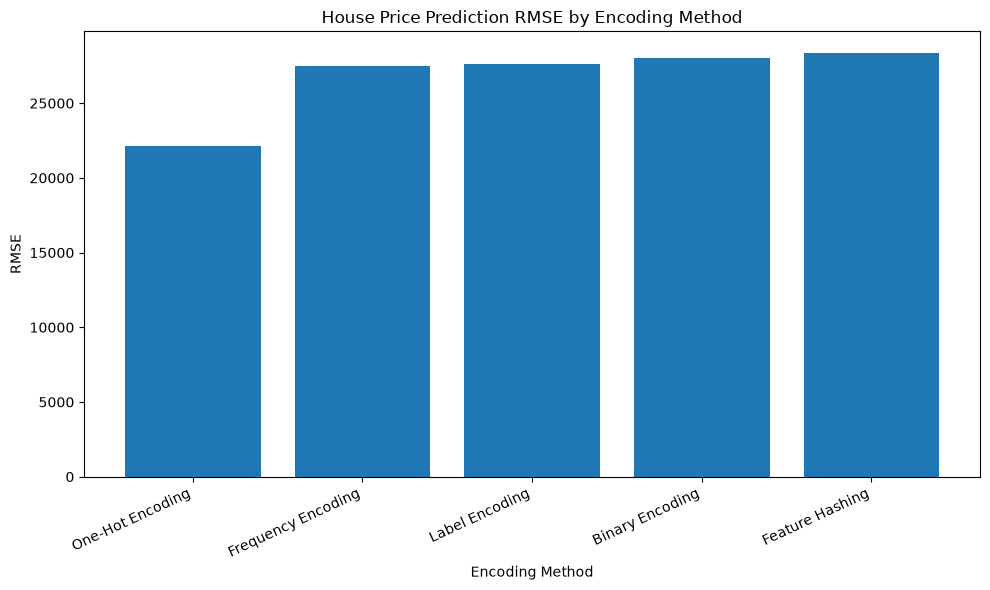

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Encoding Method"], results_df["RMSE"])
plt.xlabel("Encoding Method")
plt.ylabel("RMSE")
plt.title("House Price Prediction RMSE by Encoding Method")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


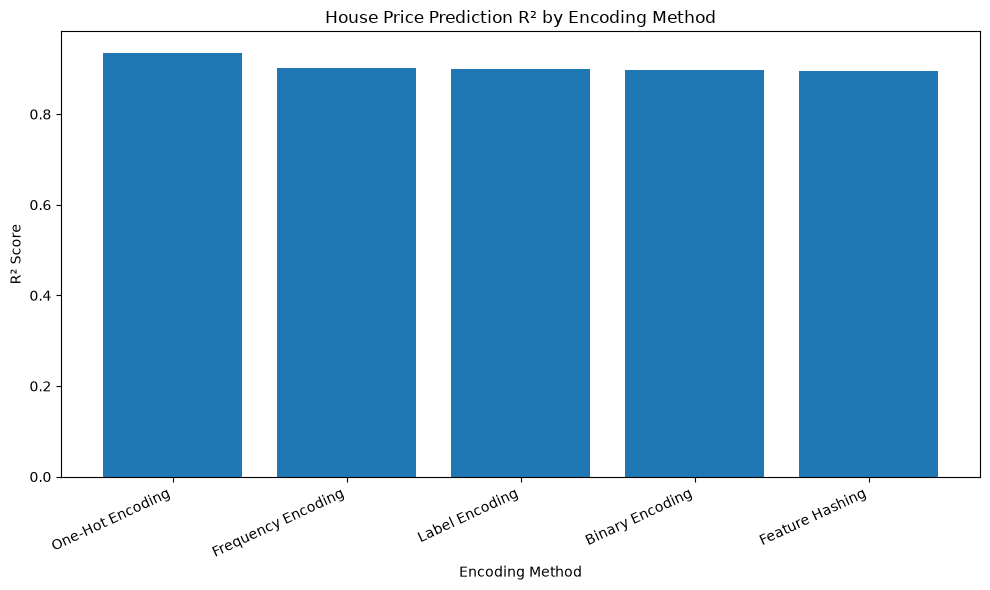

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Encoding Method"], results_df["R2 Score"])
plt.xlabel("Encoding Method")
plt.ylabel("R² Score")
plt.title("House Price Prediction R² by Encoding Method")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# 10. Best Encoding Selection

The best encoding is selected using the lowest validation RMSE. R² is used as a complementary measure. The result is specific to this dataset, split, preprocessing strategy, and Ridge configuration; it should not be interpreted as a universal ranking of encoding methods.


In [19]:
best_result = results_df.iloc[0]
best_method = best_result["Encoding Method"]
print("Best encoding method:", best_method)
print("Validation RMSE:", round(best_result["RMSE"], 2))
print("Validation R²:", round(best_result["R2 Score"], 4))
print("Encoded feature count:", int(best_result["Number of Features"]))


Best encoding method: One-Hot Encoding
Validation RMSE: 22167.46
Validation R²: 0.9359
Encoded feature count: 286


# 11. Prediction and Error Analysis

The selected model is examined using actual versus predicted prices and residuals. The largest absolute errors are also displayed.


In [20]:
best_predictions = predictions_by_method[best_method]
prediction_df = pd.DataFrame({
    "Actual SalePrice": y_valid.values,
    "Predicted SalePrice": best_predictions
})
prediction_df["Absolute Error"] = (
    prediction_df["Actual SalePrice"] - prediction_df["Predicted SalePrice"]
).abs()
display(prediction_df.sort_values("Absolute Error", ascending=False).head(15))


,Actual SalePrice,Predicted SalePrice,Absolute Error
43,253293,371602.003843,118309.003843
74,611657,503586.075125,108070.924875
260,395000,301560.509709,93439.490291
278,143000,214262.815335,71262.815335
152,200624,270340.661091,69716.661091
6,311500,249607.895558,61892.104442
214,241500,182843.115855,58656.884145
168,556581,499497.977694,57083.022306
167,276000,332738.441397,56738.441397
243,438780,492666.118801,53886.118801


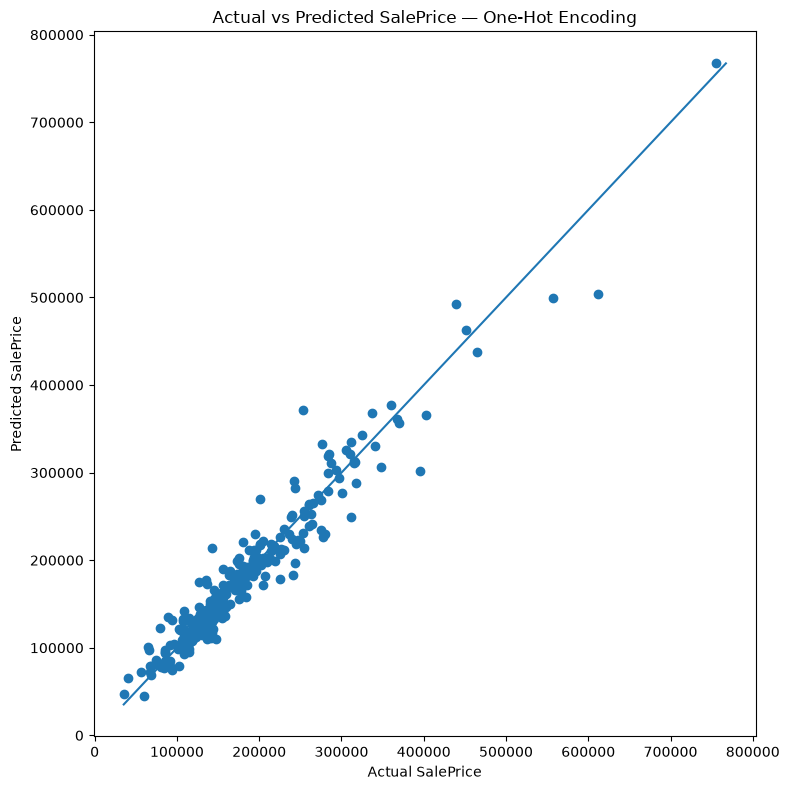

In [21]:
plt.figure(figsize=(8, 8))
plt.scatter(prediction_df["Actual SalePrice"], prediction_df["Predicted SalePrice"])
minimum_price = min(prediction_df["Actual SalePrice"].min(), prediction_df["Predicted SalePrice"].min())
maximum_price = max(prediction_df["Actual SalePrice"].max(), prediction_df["Predicted SalePrice"].max())
plt.plot([minimum_price, maximum_price], [minimum_price, maximum_price])
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Actual vs Predicted SalePrice — {best_method}")
plt.tight_layout()
plt.show()


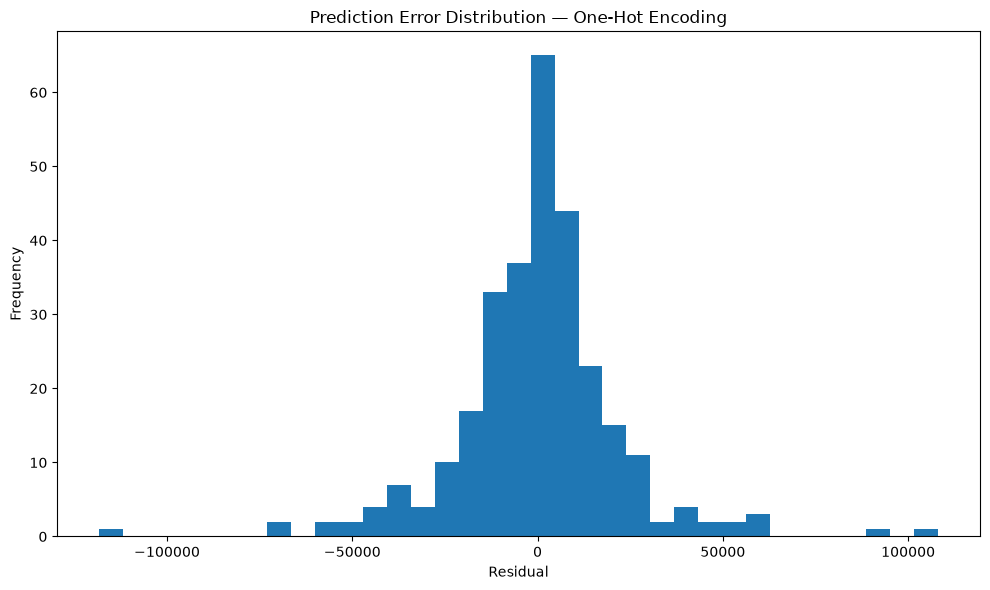

In [22]:
residuals = prediction_df["Actual SalePrice"] - prediction_df["Predicted SalePrice"]
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=35)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution — {best_method}")
plt.tight_layout()
plt.show()


# 12. Model Export

The deployment artifact must preserve the preprocessing representation and regression model. For the best-performing Frequency Encoding approach, the final model is retrained on the full labelled training dataset using frequency mappings calculated from the complete training data.


In [23]:
if best_method == "Frequency Encoding":
    final_X = X.copy()
    final_frequency_mappings = {}
    for column in categorical_columns_full:
        filled = X[column].fillna(X[column].mode()[0])
        mapping = filled.value_counts(normalize=True).to_dict()
        final_frequency_mappings[column] = mapping
        final_X[column] = filled.map(mapping).fillna(0)
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])
    final_model.fit(final_X.values, np.log1p(y))
    model_path = BASE_PATH / "house_price_model.joblib"
    mappings_path = BASE_PATH / "frequency_mappings.json"
    dump(final_model, model_path)
    pd.Series(final_frequency_mappings, dtype=object).to_json(mappings_path)
    print("Model saved to:", model_path)
    print("Frequency mappings saved to:", mappings_path)
else:
    print("The export cell is configured for Frequency Encoding.")
    print("Selected method:", best_method)


The export cell is configured for Frequency Encoding.
Selected method: One-Hot Encoding
